In [1]:
top_features = [
    "debt_to_total_liabilities",
    "roa_ru_tax",
    "absolute_liquidity",
    "total_assets_turnover",
    "receivables_to_total_assets",
    "days_purch_outst",
    "days_sales_outst",
    "total_debt",
    "payables_turnover",
    "roe",
    "2110_revenue",
    "inventory_turnover",
    "receivables_turnover",
    "asset_conversion_period",
    "cogs_to_revenue",
    "roa",
    "net_profit_margin",
    "ebit",
    "net_debt_to equity",
    "own_working_capital_adequacy",
    "equity_concentration",
    "days_inventory_outst",
    "net_assets",
    "working_capital",
    "equity_maneuverability",
    "fa_turnover_ratio",
    "ebitm",
    "debt_to_equity",
    "gpm_on_sgna",
    "working_capital_to_total_assets",
]


In [2]:
from utils.common import prepare_dataset, data_split, train_catboost, calculate_metrics, get_most_important_features

df = prepare_dataset('../trading_small_df.csv',
                    exclude_cols=['cred_limit', 'fin_cond_index', 'tax_regime', 'reg_date', 'Unnamed: 0'], 
                    year_col='year',
                    id_col='vat_num',
                    dflt_col='dflt_year',
                    drop_fin_zeroes=True,
                    drop_ones_after_ones=True,
                    include_cols=top_features[:20])


Длина датасета: 153841
Распределение таргета:
dflt_year
0    151926
1      1915
Name: count, dtype: int64


In [3]:
X_train, y_train, X_val, y_val, X_test, y_test = data_split(df, train_year_max=2022, val_year=2023, test_year=2024, target_col="target")

model = train_catboost(X_train, 
                       y_train, 
                       X_val, 
                       y_val,
                       iterations_num=10_000,
                       eval_metric="AUC",
                       learning_rate=0.01,
                       random_seed=42,
                       verbose=200,
                       early_stopping_rounds=200,
                       class_weights=None)

0:	test: 0.8536881	best: 0.8536881 (0)	total: 64.1ms	remaining: 10m 40s
200:	test: 0.8835510	best: 0.8835889 (197)	total: 1.49s	remaining: 1m 12s
400:	test: 0.8920915	best: 0.8920915 (400)	total: 3.15s	remaining: 1m 15s
600:	test: 0.8960399	best: 0.8960399 (600)	total: 4.89s	remaining: 1m 16s
800:	test: 0.8979843	best: 0.8979843 (800)	total: 6.74s	remaining: 1m 17s
1000:	test: 0.8988334	best: 0.8988361 (994)	total: 8.49s	remaining: 1m 16s
1200:	test: 0.8993634	best: 0.8994157 (1108)	total: 12.5s	remaining: 1m 31s
1400:	test: 0.8993629	best: 0.8994936 (1289)	total: 17.4s	remaining: 1m 46s
Stopped by overfitting detector  (200 iterations wait)

bestTest = 0.899493612
bestIteration = 1289

Shrink model to first 1290 iterations.


AUC: 0.9184063850383724
Brier: 0.11423002554222016
LogLoss: 0.4664628292853723

Top 20 features by importance:
                         feature  importance
0      debt_to_total_liabilities   15.628685
1             absolute_liquidity   10.113214
2        asset_conversion_period    7.964371
3                     roa_ru_tax    5.947457
4                            roa    5.904959
5                     total_debt    5.353448
6                   2110_revenue    5.283808
7          total_assets_turnover    5.221963
8                cogs_to_revenue    4.432784
9    receivables_to_total_assets    4.234481
10             net_profit_margin    3.924565
11                           roe    3.688280
12             payables_turnover    3.381139
13          receivables_turnover    3.208691
14                          ebit    3.050044
15              days_purch_outst    3.027028
16              days_sales_outst    2.964065
17            inventory_turnover    2.655603
18            net_debt_to equity  

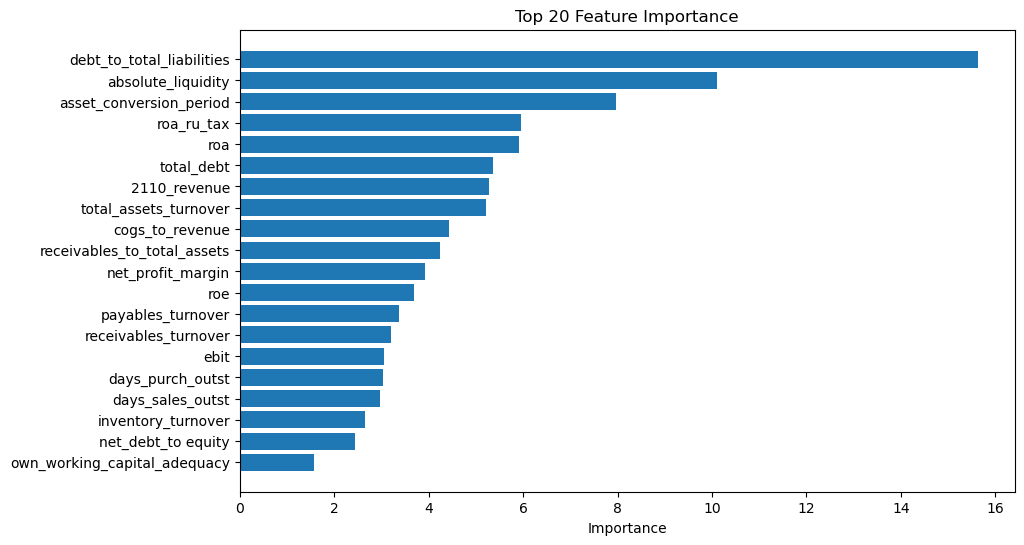

In [4]:
metrics = calculate_metrics(model, X_test, y_test)
fi_df = get_most_important_features(model, show=20)

In [5]:
from utils.common import calibrate_model

calibrated_model = calibrate_model(model, X_val, y_val)

In [6]:
calibrated_metrics = calculate_metrics(calibrated_model, X_test, y_test)

AUC: 0.9139887278823987
Brier: 0.09383245746345213
LogLoss: 0.3144865325993351


In [7]:
from utils.exp_handler import save_exp

save_exp(X_train, 
         y_train, 
         X_val, 
         y_val, 
         X_test, 
         y_test,
         model,
         metrics=calibrated_metrics,
         fi_df=fi_df,
         calibrated_model=calibrated_model,
         name='small_df_no_lags_top20features',
         save_data=False)

'exp/small_df_no_lags_top20features'